In [1]:
import carla
import math
import random
import time
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from transformers import OwlViTProcessor, OwlViTForObjectDetection
from ultralytics import SAM
import torch
from PIL import Image
import cv2
import numpy as np
import torchvision

# Variable Initialization
camera_image = None

# Carla Initialization
client = carla.Client('localhost', 2000)
world = client.get_world()
bp_lib = world.get_blueprint_library()

# Vehicle Spawning and Selection
spawn_points = world.get_map().get_spawn_points()
vehicle_bp = bp_lib.find('vehicle.lincoln.mkz_2020')

In [2]:
def cleanup_carla():
    """Clean up all CARLA actors and sensors"""
    try:
        # Stop camera
        if 'camera' in globals() and camera is not None:
            camera.stop()
            camera.destroy()
        
        # Destroy ego vehicle
        if 'vehicle' in globals() and vehicle is not None:
            vehicle.destroy()
        
        # Destroy all actors
        for actor in world.get_actors():
            if actor.type_id.startswith('vehicle') or actor.type_id.startswith('sensor'):
                actor.destroy()
        
        # Reset settings
        settings = world.get_settings()
        settings.synchronous_mode = False
        world.apply_settings(settings)
        
        print("✓ CARLA cleaned up successfully!")
    except Exception as e:
        print(f"Error during cleanup: {e}")

# Call it when done
cleanup_carla()

✓ CARLA cleaned up successfully!


In [3]:
# ============================================
# CELL 1: VEHICLE AND CAMERA SETUP
# ============================================

# Ego Vehicle Selection 
vehicle = world.try_spawn_actor(vehicle_bp, random.choice(spawn_points))

# Surrounding Vehicle Selection
for i in range(30):
    vehicle_bp_npc = random.choice(bp_lib.filter('vehicle'))
    npc = world.try_spawn_actor(vehicle_bp_npc, random.choice(spawn_points))

# Vehicle Control Initialization
for v in world.get_actors().filter('*vehicle*'):
    v.set_autopilot(True)

# ============================================
# CAMERA SETUP - TWO VIEWS
# ============================================

# Camera Blueprint
camera_bp = bp_lib.find('sensor.camera.semantic_segmentation')

# FV Camera (Forward View) - at eye level, looking forward
camera_init_trans_fv = carla.Transform(carla.Location(z=2))
camera_fv = world.spawn_actor(camera_bp, camera_init_trans_fv, attach_to=vehicle)

# BEV Camera (Bird's Eye View) - high above, looking down
camera_init_trans_bev = carla.Transform(carla.Location(z=50), carla.Rotation(pitch=-90))
camera_bev = world.spawn_actor(camera_bp, camera_init_trans_bev, attach_to=vehicle)

Waiting for camera frames...
✅ Both camera frames received


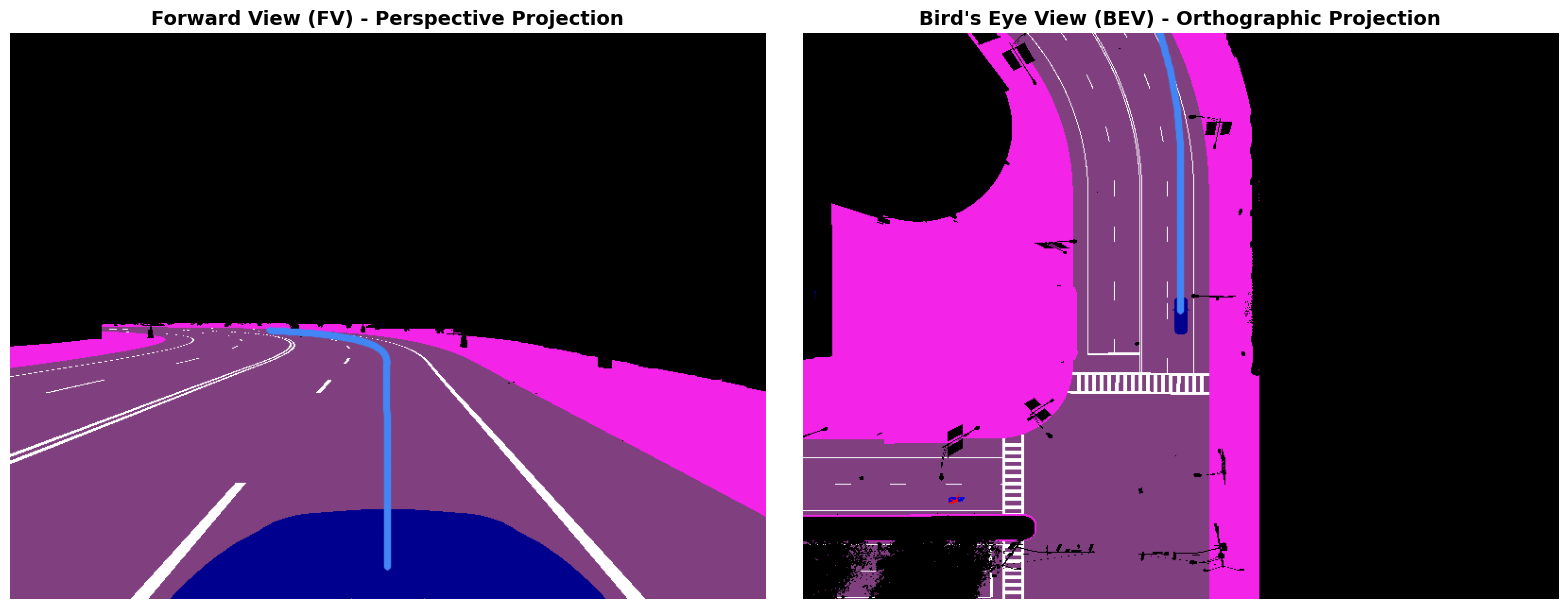

In [4]:
# ============================================
# CELL 2: IMAGE PROCESSING - DUAL VIEW
# ============================================

import warnings
warnings.filterwarnings('ignore')
import numpy as np
from PIL import Image
import time
import matplotlib.pyplot as plt
import cv2

# Global variables to store camera images
camera_image_fv = None
camera_image_bev = None

def process_image_fv(data):    
    """Process Forward View camera image"""
    global camera_image_fv
    
    # Convert raw data to numpy array
    array = np.frombuffer(data.raw_data, dtype=np.dtype("uint8"))
    array = np.reshape(array, (data.height, data.width, 4))  # BGRA
    
    # CARLA semantic segmentation uses the RED channel for class labels
    semantic_tags = array[:, :, 2]  # Red channel
    
    # Create RGB output image - start with black
    height, width = semantic_tags.shape
    denoised_image = np.zeros((height, width, 3), dtype=np.uint8)
    
    # Define color mapping using CARLA's actual class IDs
    carla_to_color = {
        1: [128, 64, 128],      # Roads -> Purple
        14: [0, 0, 142],        # Car -> Dark blue
        15: [0, 0, 70],         # Truck -> Dark blue (similar)
        16: [0, 60, 100],       # Bus -> Dark cyan
        18: [0, 0, 230],        # Motorcycle -> Blue
        12: [220, 20, 60],      # Pedestrian -> Red
        13: [255, 0, 0],        # Rider -> Red (similar)
        24: [255, 255, 255],    # RoadLine -> White
        2: [244, 35, 232],      # SideWalks -> Pink/Magenta
    }
    
    # Apply color mapping
    for class_id, color in carla_to_color.items():
        mask = semantic_tags == class_id
        denoised_image[mask] = color
    
    # Get vehicle info
    vehicle_location = vehicle.get_location()
    vehicle_transform = vehicle.get_transform()
    carla_map = world.get_map()
    
    # Get current waypoint
    current_waypoint = carla_map.get_waypoint(vehicle_location)
    
    # Collect waypoints
    waypoints = []
    wp = current_waypoint
    
    for i in range(100):
        next_wps = wp.next(0.5)
        if not next_wps:
            break
        wp = next_wps[0]
        waypoints.append(wp)
    
    # ========================================
    # FV: PERSPECTIVE PROJECTION
    # ========================================
    
    camera_transform = camera_fv.get_transform()
    camera_location = camera_transform.location
    
    # Camera intrinsics
    image_w = width
    image_h = height
    fov = 90.0
    
    focal = image_w / (2.0 * np.tan(fov * np.pi / 360.0))
    
    K = np.array([
        [focal, 0.0, image_w / 2.0],
        [0.0, focal, image_h / 2.0],
        [0.0, 0.0, 1.0]
    ])
    
    # Get camera basis vectors
    forward = camera_transform.get_forward_vector()
    right = camera_transform.get_right_vector()
    up = camera_transform.get_up_vector()
    
    # Extract lane center points
    center_points = []
    
    for wp in waypoints:
        # Translate to camera origin
        dx = wp.transform.location.x - camera_location.x
        dy = wp.transform.location.y - camera_location.y
        dz = wp.transform.location.z - camera_location.z
        
        # Transform to camera space
        camera_x = dx * right.x + dy * right.y + dz * right.z
        camera_y = -(dx * up.x + dy * up.y + dz * up.z)
        camera_z = dx * forward.x + dy * forward.y + dz * forward.z
        
        # Filter points behind camera
        if camera_z <= 0.1:
            continue
        
        # Perspective projection
        point_3d = np.array([camera_x, camera_y, camera_z])
        point_2d = K @ point_3d
        
        pixel_x = int(point_2d[0] / point_2d[2])
        pixel_y = int(point_2d[1] / point_2d[2])
        
        if 0 <= pixel_x < width and 0 <= pixel_y < height:
            center_points.append((pixel_x, pixel_y))
    
    # Draw blue path line
    if len(center_points) > 1:
        center_array = np.array(center_points, dtype=np.int32)
        cv2.polylines(denoised_image, [center_array], False, (66, 133, 244), 5, cv2.LINE_AA)
    
    camera_image_fv = denoised_image


def process_image_bev(data):    
    """Process Bird's Eye View camera image"""
    global camera_image_bev
    
    # Convert raw data to numpy array
    array = np.frombuffer(data.raw_data, dtype=np.dtype("uint8"))
    array = np.reshape(array, (data.height, data.width, 4))  # BGRA
    
    # CARLA semantic segmentation uses the RED channel for class labels
    semantic_tags = array[:, :, 2]  # Red channel
    
    # Create RGB output image - start with black
    height, width = semantic_tags.shape
    denoised_image = np.zeros((height, width, 3), dtype=np.uint8)
    
    # Define color mapping using CARLA's actual class IDs
    carla_to_color = {
        1: [128, 64, 128],      # Roads -> Purple
        14: [0, 0, 142],        # Car -> Dark blue
        15: [0, 0, 70],         # Truck -> Dark blue (similar)
        16: [0, 60, 100],       # Bus -> Dark cyan
        18: [0, 0, 230],        # Motorcycle -> Blue
        12: [220, 20, 60],      # Pedestrian -> Red
        13: [255, 0, 0],        # Rider -> Red (similar)
        24: [255, 255, 255],    # RoadLine -> White
        2: [244, 35, 232],      # SideWalks -> Pink/Magenta
    }
    
    # Apply color mapping
    for class_id, color in carla_to_color.items():
        mask = semantic_tags == class_id
        denoised_image[mask] = color
    
    # Get vehicle info
    vehicle_location = vehicle.get_location()
    vehicle_transform = vehicle.get_transform()
    carla_map = world.get_map()
    
    # Get current waypoint
    current_waypoint = carla_map.get_waypoint(vehicle_location)
    
    # Collect waypoints
    waypoints = []
    wp = current_waypoint
    
    for i in range(100):
        next_wps = wp.next(0.5)
        if not next_wps:
            break
        wp = next_wps[0]
        waypoints.append(wp)
    
    # ========================================
    # BEV: ORTHOGRAPHIC PROJECTION
    # ========================================
    
    camera_location = camera_bev.get_transform().location
    center_x, center_y = width // 2, height // 2
    pixels_per_meter = 10
    vehicle_yaw = np.deg2rad(vehicle_transform.rotation.yaw)
    
    # Rotation: 270° counter-clockwise
    rotation_angle = vehicle_yaw - np.pi / 2
    
    # Extract lane center points
    center_points = []
    
    for wp in waypoints:
        dx = wp.transform.location.x - camera_location.x
        dy = wp.transform.location.y - camera_location.y
        
        # Apply 270° counter-clockwise rotation + vehicle yaw
        rotated_x = dx * np.cos(rotation_angle) + dy * np.sin(rotation_angle)
        rotated_y = -dx * np.sin(rotation_angle) + dy * np.cos(rotation_angle)
        
        # Mirror horizontally
        rotated_x = -rotated_x
        
        pixel_x = int(center_x + rotated_x * pixels_per_meter)
        pixel_y = int(center_y - rotated_y * pixels_per_meter)
        
        if 0 <= pixel_x < width and 0 <= pixel_y < height:
            center_points.append((pixel_x, pixel_y))
    
    # Draw blue line
    if len(center_points) > 1:
        center_array = np.array(center_points, dtype=np.int32)
        cv2.polylines(denoised_image, [center_array], False, (66, 133, 244), 5, cv2.LINE_AA)
    
    camera_image_bev = denoised_image


# Listen to both cameras
camera_fv.listen(process_image_fv)
camera_bev.listen(process_image_bev)

# Wait for both frames to be captured
print("Waiting for camera frames...")
while camera_image_fv is None or camera_image_bev is None:
    time.sleep(0.1)

print("✅ Both camera frames received")

# ============================================
# DISPLAY BOTH VIEWS
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Forward View
axes[0].imshow(camera_image_fv)
axes[0].set_title('Forward View (FV) - Perspective Projection', fontsize=14, fontweight='bold')
axes[0].axis('off')

# Bird's Eye View
axes[1].imshow(camera_image_bev)
axes[1].set_title("Bird's Eye View (BEV) - Orthographic Projection", fontsize=14, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()

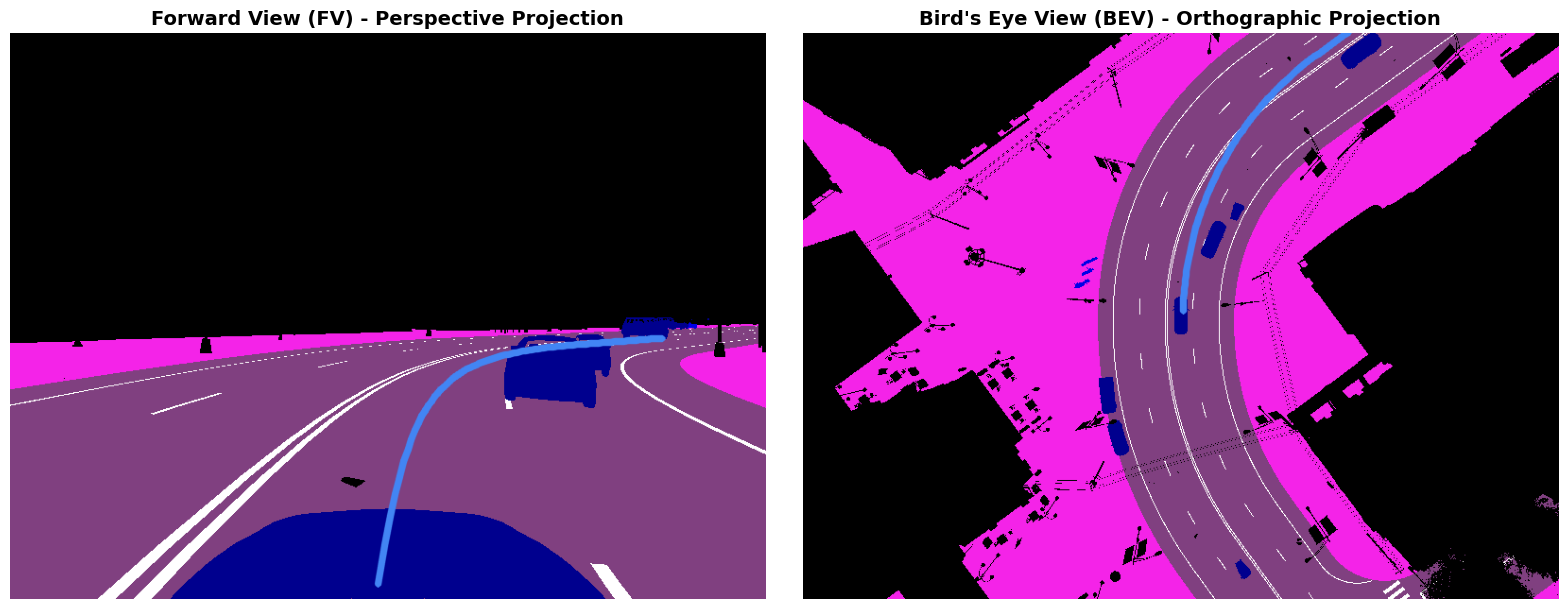

In [161]:
# ============================================
# DISPLAY BOTH VIEWS
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Forward View
axes[0].imshow(camera_image_fv)
axes[0].set_title('Forward View (FV) - Perspective Projection', fontsize=14, fontweight='bold')
axes[0].axis('off')

# Bird's Eye View
axes[1].imshow(camera_image_bev)
axes[1].set_title("Bird's Eye View (BEV) - Orthographic Projection", fontsize=14, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Return Vehicle Lanes
vehicle_position = vehicle.get_location()
map = world.get_map()

# Lane Initialization
left_lane = False
right_lane = False

current_waypoint = map.get_waypoint(location = vehicle_position)
left_waypoint = current_waypoint.get_left_lane() 
right_waypoint = current_waypoint.get_right_lane()

# Return the Lane Existence
if current_waypoint is not None: # Check Current Lane
    if current_waypoint.lane_type == carla.libcarla.LaneType.Driving:
        current_lane = True
else:
    current_lane = False

if left_waypoint is not None: # Check Left Lane
    if left_waypoint.lane_type == carla.libcarla.LaneType.Driving:
        left_lane = True
else:
    left_lane = False

if right_waypoint is not None: # Check Right Lane
    if right_waypoint.lane_type == carla.libcarla.LaneType.Driving:
        right_lane = True
else:
    right_lane = False

lanes = pd.DataFrame([current_lane, left_lane, right_lane])
lane_state = pd.get_dummies(lanes)

lane_state